# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR-USERNAME/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb)

**Lane 3 — Structured Content Archetype Clustering.**

ML-07 froze a five-rung hand-written ladder. Its biggest failure was named there: **43% of the inventory
lands in a `STEADY_LOW` catch-all with a single `monitor` between 8,130 pages.** This notebook asks whether
K-Means can see structure the ladder cannot.

**The short version: yes, and the specific thing it finds is worth the seven weeks — but by my own ML-03
test the clustering does less decision work than it first appears.** Six clusters collapse to four distinct
actions, and I report that rather than inventing a distinction to justify the sixth.

> Skills for this card: `skills/training-honest-models/SKILL.md` + `skills/flyrank/flyrank-data/SKILL.md`.
> Data: `data/raw/content_refresh_anonymized.csv` — **the same inventory and the same filters as ML-07**,
> because a comparison on different data is not a comparison. Seed 42 throughout.

In [ ]:
import os, sys, json, subprocess, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

SEED = 42
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/ZainDev04/Flyrank-ML-Internship"   # <-- change to YOUR fork
CSV_REL  = "data/raw/content_refresh_anonymized.csv"
if IN_COLAB and not Path(CSV_REL).exists():
    if not os.path.isdir("flyrank-ml-internship"):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, "flyrank-ml-internship"], check=True)
    os.chdir("flyrank-ml-internship")
else:
    here = Path.cwd()
    for c in [here, *here.parents]:
        if (c / CSV_REL).exists():
            os.chdir(c); break
assert Path(CSV_REL).exists()
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
print(f"python {sys.version.split()[0]} | sklearn {sklearn.__version__} | "
      f"pandas {pd.__version__} | seed {SEED}")

python 3.11.15 | sklearn 1.8.0 | pandas 3.0.2 | seed 42


In [2]:
# ---- Rebuild the ML-07 inventory EXACTLY, then re-run its frozen ladder. ----
MIN_IMPRESSIONS, K = 300, 6

df = pd.read_csv(CSV_REL)
d = df[(df["impressions_90d"] >= MIN_IMPRESSIONS) & (df["avg_position"] > 0)].copy()
d["log_impressions"] = np.log1p(d["impressions_90d"])
d["log_clicks"] = np.log1p(d["clicks_90d"])
d["log_sessions"] = np.log1p(d["sessions_90d"])
d["impression_consistency"] = d["days_with_impressions"] / 90
d = d.reset_index(drop=True)

def ladder(r):                                    # the FROZEN ML-07 baseline, unchanged
    if r["impressions_90d"] >= 3000 and r["avg_position"] <= 10:          return "CHAMPION"
    if r["days_since_last_update"] >= 90 and r["impressions_90d"] >= 500: return "STALE_VISIBLE"
    if r["engagement_rate"] >= 10:                                        return "ENGAGED_NICHE"
    if r["days_with_impressions"] < 45:                                   return "INTERMITTENT"
    return "STEADY_LOW"
d["rule_archetype"] = d.apply(ladder, axis=1)

FROZEN = {"STEADY_LOW": 8130, "STALE_VISIBLE": 4891, "CHAMPION": 4571,
          "ENGAGED_NICHE": 903, "INTERMITTENT": 257}
repro = {k: int(v) for k, v in d["rule_archetype"].value_counts().items()}
print(f"inventory: {len(d):,} pages / {d['client_id'].nunique()} clients")
print(f"ML-07 frozen ladder : {FROZEN}")
print(f"reproduced here     : {repro}")
assert repro == FROZEN, "the ML-07 baseline did not reproduce - the inventory has drifted"
print("\nMatch. Same inventory, same ladder. The comparison below is legitimate.")

inventory: 18,752 pages / 29 clients
ML-07 frozen ladder : {'STEADY_LOW': 8130, 'STALE_VISIBLE': 4891, 'CHAMPION': 4571, 'ENGAGED_NICHE': 903, 'INTERMITTENT': 257}
reproduced here     : {'STEADY_LOW': 8130, 'STALE_VISIBLE': 4891, 'CHAMPION': 4571, 'ENGAGED_NICHE': 903, 'INTERMITTENT': 257}

Match. Same inventory, same ladder. The comparison below is legitimate.


## 1. Method choice and why

**K-Means, k = 6.** The `training-honest-models` table maps *"grouping items"* to *K-Means (pick k with
silhouette), then NAME clusters after inspecting them*, and that is what this lane needs.

But "K-Means because the table said so" is not a method choice, it is obedience. So I ran the two obvious
alternatives on the same features, the same scaling and the same k, and compared them on the metric ML-03
committed to.

In [3]:
FEATURES = ["log_impressions", "log_clicks", "ctr", "avg_position", "log_sessions",
            "engagement_rate", "impression_consistency", "content_age_days",
            "days_since_last_update"]
scaler = StandardScaler().fit(d[FEATURES].fillna(d[FEATURES].median()))
X = scaler.transform(d[FEATURES].fillna(d[FEATURES].median()))

km = KMeans(n_clusters=K, n_init=25, random_state=SEED).fit(X)
d["cluster"] = km.labels_
gm = GaussianMixture(n_components=K, random_state=SEED, n_init=5).fit_predict(X)

samp = np.random.RandomState(0).choice(len(X), 5000, replace=False)
sub = np.random.RandomState(1).choice(len(X), 6000, replace=False)
agg = AgglomerativeClustering(n_clusters=K).fit_predict(X[sub])   # O(n^2) memory - subsample

print(f"Method comparison at k={K}, same features, same scaling:\n")
print(f"  {'KMeans':22s} silhouette={silhouette_score(X[samp], km.labels_[samp]):.3f}  "
      f"sizes={sorted(pd.Series(km.labels_).value_counts().tolist())}")
print(f"  {'GaussianMixture':22s} silhouette={silhouette_score(X[samp], gm[samp]):.3f}  "
      f"sizes={sorted(pd.Series(gm).value_counts().tolist())}")
print(f"  {'Agglomerative (6k)':22s} silhouette={silhouette_score(X[sub], agg):.3f}  "
      f"sizes={sorted(pd.Series(agg).value_counts().tolist())}")
print(f"\n  ARI(KMeans, GaussianMixture)        = {adjusted_rand_score(km.labels_, gm):.3f}")
print(f"  ARI(KMeans, Agglomerative) on 6,000 = {adjusted_rand_score(km.labels_[sub], agg):.3f}")

Method comparison at k=6, same features, same scaling:

  KMeans                 silhouette=0.221  sizes=[537, 985, 3595, 4113, 4598, 4924]
  GaussianMixture        silhouette=0.116  sizes=[1241, 1320, 2766, 3851, 4466, 5108]
  Agglomerative (6k)     silhouette=0.141  sizes=[225, 257, 1119, 1175, 1436, 1788]

  ARI(KMeans, GaussianMixture)        = 0.288
  ARI(KMeans, Agglomerative) on 6,000 = 0.411


**Read.** K-Means wins on the metric I committed to in ML-03 — silhouette **0.221** against Gaussian
Mixture's **0.116** and Agglomerative's **0.141** — and it is the only one of the three that produces
balanced, usable group sizes. Agglomerative on a 6,000-page subsample returns clusters as small as 225,
which is not a policy unit.

The ARIs are the interesting part: **0.288** between K-Means and Gaussian Mixture means the two methods
find *substantially different* partitions of the same data. That is a caution I am carrying forward — the
groups below are not "the" structure in this inventory, they are the structure K-Means finds. A different
method would hand a content lead a different set of policies. My defence for preferring K-Means is that it
separates better and produces groups a human can act on, not that it is uniquely correct.

**Why not the more complex option.** Gaussian Mixture is the more expressive model — it allows elliptical,
overlapping clusters where K-Means forces spheres. On paper it should do better. It scores half the
silhouette. Complexity earned nothing here, so I am not shipping it.

## 2. Split design

Clustering has no train/test split in the supervised sense — there is no label to hold out. But "no split"
is not the same as "no validation design", and ML-03 committed to three checks. Two are re-run here; the
third is new and is the one I trust most.

In [4]:
base = km.labels_
seed_ari = [adjusted_rand_score(base, KMeans(n_clusters=K, n_init=25, random_state=s).fit_predict(X))
            for s in (1, 7, 13, 99, 2024)]
sub_ari = []
for s in (1, 7, 13, 99, 2024):
    idx = np.random.RandomState(s).choice(len(X), int(0.8 * len(X)), replace=False)
    sub_ari.append(adjusted_rand_score(base[idx],
                   KMeans(n_clusters=K, n_init=25, random_state=SEED).fit_predict(X[idx])))
print(f"CHECK 1 - seed stability      : mean ARI {np.mean(seed_ari):.3f}  {np.round(seed_ari,3).tolist()}")
print(f"CHECK 2 - subsample stability : mean ARI {np.mean(sub_ari):.3f}  {np.round(sub_ari,3).tolist()}")
print(f"          (ML-03 bar was 0.80 for both)\n")

print("CHECK 3 - CLIENT-GROUPED HOLDOUT: do the clusters transfer to clients never seen?")
print("  Fit K-Means WITHOUT six clients, then assign those clients' pages to the fitted")
print("  centroids and compare against what the full model said about them.\n")
rng = np.random.RandomState(SEED)
clients = d["client_id"].unique()
holdout_ari = []
for rep in range(3):
    hold = rng.choice(clients, 6, replace=False)
    tr, te = d[~d["client_id"].isin(hold)], d[d["client_id"].isin(hold)]
    kmt = KMeans(n_clusters=K, n_init=25, random_state=SEED).fit(scaler.transform(
        tr[FEATURES].fillna(d[FEATURES].median())))
    assigned = kmt.predict(scaler.transform(te[FEATURES].fillna(d[FEATURES].median())))
    a = adjusted_rand_score(base[te.index], assigned)
    holdout_ari.append(a)
    print(f"  rep {rep}: {len(hold)} clients held out ({len(te):5,} pages) -> ARI {a:.3f}")
print(f"\n  mean {np.mean(holdout_ari):.3f}, range {min(holdout_ari):.3f}-{max(holdout_ari):.3f}")

CHECK 1 - seed stability      : mean ARI 0.998  [0.999, 1.0, 1.0, 0.995, 0.997]
CHECK 2 - subsample stability : mean ARI 0.991  [0.995, 0.993, 0.985, 0.989, 0.992]
          (ML-03 bar was 0.80 for both)

CHECK 3 - CLIENT-GROUPED HOLDOUT: do the clusters transfer to clients never seen?
  Fit K-Means WITHOUT six clients, then assign those clients' pages to the fitted
  centroids and compare against what the full model said about them.

  rep 0: 6 clients held out (1,525 pages) -> ARI 0.589
  rep 1: 6 clients held out (4,985 pages) -> ARI 0.905
  rep 2: 6 clients held out (2,924 pages) -> ARI 0.933

  mean 0.809, range 0.589-0.933


**Read.** Seeds and subsamples are near-perfect (0.998, 0.991) — but those are easy tests. They only
show K-Means is deterministic given the data.

The client-grouped holdout is the real one, and it is **more honest and less flattering: ARI 0.589 to
0.933, mean 0.809.** Two of three replicates transfer well; one drops to 0.589, meaning that for that
particular set of six clients, a model that had never seen them placed a substantial share of their pages
in different groups than the full model did.

**What that costs me.** These archetypes are *mostly* portable to a client the model has not seen, but not
reliably so. A content lead onboarding a new client should not assume the six groups will apply cleanly to
them on day one. That is a real limitation of a 29-client panel, and it belongs in the write-up rather than
in a footnote.

## 3. Train + compare vs my baseline

### The comparison table

In [5]:
ari_ladder = adjusted_rand_score(d["cluster"], d["rule_archetype"])
sil_km = silhouette_score(X[samp], km.labels_[samp])

# the ladder scored on the SAME metric, as a partition of the SAME feature space
ladder_codes = pd.factorize(d["rule_archetype"])[0]
sil_ladder = silhouette_score(X[samp], ladder_codes[samp])
ladder_seed = 1.0    # a deterministic rule is trivially stable - stated, not measured

comparison = pd.DataFrame([
    {"method": "Hand-written ladder (frozen ML-07)", "groups": d["rule_archetype"].nunique(),
     "silhouette": sil_ladder, "seed_stability_ARI": ladder_seed,
     "client_holdout_ARI": np.nan, "smallest_group": int(d["rule_archetype"].value_counts().min())},
    {"method": "K-Means (k=6)", "groups": K, "silhouette": sil_km,
     "seed_stability_ARI": np.mean(seed_ari), "client_holdout_ARI": np.mean(holdout_ari),
     "smallest_group": int(pd.Series(km.labels_).value_counts().min())},
    {"method": "Gaussian Mixture (k=6)", "groups": K,
     "silhouette": silhouette_score(X[samp], gm[samp]), "seed_stability_ARI": np.nan,
     "client_holdout_ARI": np.nan, "smallest_group": int(pd.Series(gm).value_counts().min())},
]).set_index("method")
print("SAME inventory, SAME feature space, SAME metric\n")
print(comparison.round(3).to_string())
print(f"\nAgreement between the learned clusters and the frozen ladder: ARI = {ari_ladder:.3f}")
print(f"\nThe ladder is a partition of the same space, so silhouette applies to it too:")
print(f"  ladder {sil_ladder:.3f} vs K-Means {sil_km:.3f} - the learned groups are roughly "
      f"{sil_km/sil_ladder:.1f}x more compact.")
print("The ladder is not incoherent - 0.120 is positive, its rungs do track something real.")
print("It is just that its edges are policy thresholds rather than the data's own density,")
print("so it cuts across regions the data keeps together. That is what clustering adds here:")
print("not 'the ladder is wrong', but 'the ladder's boundaries are mine, not the inventory's'.")

SAME inventory, SAME feature space, SAME metric

                                    groups  silhouette  seed_stability_ARI  client_holdout_ARI  smallest_group
method                                                                                                        
Hand-written ladder (frozen ML-07)       5       0.120               1.000                 NaN             257
K-Means (k=6)                            6       0.221               0.998               0.809             537
Gaussian Mixture (k=6)                   6       0.116                 NaN                 NaN            1241

Agreement between the learned clusters and the frozen ladder: ARI = 0.288

The ladder is a partition of the same space, so silhouette applies to it too:
  ladder 0.120 vs K-Means 0.221 - the learned groups are roughly 1.8x more compact.
The ladder is not incoherent - 0.120 is positive, its rungs do track something real.
It is just that its edges are policy thresholds rather than the data's ow

In [6]:
print("Where the two partitions land (rows = learned cluster, normalised across the row):\n")
print(pd.crosstab(d["cluster"], d["rule_archetype"], normalize="index").round(2).to_string())
print("\nRead it as: which rung does each learned cluster mostly correspond to?")
print("  - three learned clusters map cleanly onto a rung (the ladder got those right)")
print("  - two learned clusters are ~80% the SAME rung as each other - STEADY_LOW - which")
print("    means the ladder put two different populations in one bucket")

Where the two partitions land (rows = learned cluster, normalised across the row):

rule_archetype  CHAMPION  ENGAGED_NICHE  INTERMITTENT  STALE_VISIBLE  STEADY_LOW
cluster                                                                         
0                   0.13           0.05          0.00           0.01        0.81
1                   0.12           0.00          0.00           0.76        0.11
2                   0.60           0.01          0.00           0.24        0.15
3                   0.03           0.05          0.26           0.06        0.60
4                   0.13           0.05          0.00           0.00        0.82
5                   0.08           0.69          0.00           0.23        0.00

Read it as: which rung does each learned cluster mostly correspond to?
  - three learned clusters map cleanly onto a rung (the ladder got those right)
  - two learned clusters are ~80% the SAME rung as each other - STEADY_LOW - which
    means the ladder put two diff

### The headline: opening the catch-all

ML-07's own verdict was that `STEADY_LOW` — 8,130 pages, 43% of the inventory, one `monitor` between all of
them — was the ladder's biggest failure. This is the test.

In [7]:
steady = d[d["rule_archetype"] == "STEADY_LOW"]
inside = steady.groupby("cluster").agg(
    pages=("content_id", "size"),
    impressions=("impressions_90d", "median"), ctr=("ctr", "median"),
    position=("avg_position", "median"), consistency=("impression_consistency", "median"),
    age_days=("content_age_days", "median"), since_update=("days_since_last_update", "median"),
    word_count=("word_count", "median"), clients=("client_id", "nunique"),
).sort_values("pages", ascending=False)
print(f"The ladder's catch-all holds {len(steady):,} pages and gives them one action: monitor.")
print("K-Means splits it into:\n")
print(inside.round(2).to_string())

The ladder's catch-all holds 8,130 pages and gives them one action: monitor.
K-Means splits it into:

         pages  impressions   ctr  position  consistency  age_days  since_update  word_count  clients
cluster                                                                                              
4         3365       1339.0  0.15      13.4         0.94     123.0          20.0      2879.0       22
0         2920       1200.0  0.09      17.8         0.98     445.0          22.0      2784.0       14
2          735      10620.0  0.42      14.4         0.98     147.0          20.0      3009.0       18
3          588        430.0  0.00      12.8         0.66     144.0          20.0      2689.0       24
1          522        399.0  0.00      17.4         0.87     284.0         104.0      2582.0       13


**Read — this is the finding.** The ladder's single `monitor` bucket contains at least four genuinely
different populations:

- **2,920 pages with a median age of 445 days** — well over a year old, consistently exposed, CTR 0.09%.
  These have had their chance and settled.
- **3,365 pages with a median age of 123 days** — nearly the same impressions (1,339 vs 1,200) and the same
  position band, but a *third* of the age and a better CTR (0.15% vs 0.09%). These may still be climbing.
- **735 pages with a median of 10,620 impressions and 0.42% CTR.** These are not "steady low" by any
  reading. They failed the `CHAMPION` rung only because their median position is 14.4 rather than ≤ 10 —
  the threshold cliff ML-07 predicted, catching high-volume pages and calling them unremarkable.
- **588 pages with impression consistency 0.66** — appearing on two thirds of days. Genuinely intermittent,
  but above the ladder's 45-day line, so it never noticed.

An old page that has plateaued and a four-month-old page still establishing itself are the same row to the
ladder and warrant opposite treatments. That distinction is what the clustering bought, and I did not know
to encode it — ML-02 wrote down that age was not in the ladder and that adding it would just create a new
fixed edge.

**The honest counter-argument, restated from ML-03.** Now that I know age matters, I could add an age rung
and the ladder would find this too. That objection holds. What it does not explain away is *how* I found
out — and on the warehouse, with far more columns and no intuition about most of them, that is the whole
value of the unsupervised pass.

## 4. Errors and interpretation

### Profiles first, names second

The lane guide's specific warning for Lane 3 is *don't name clusters before inspecting what is in them*.
So: the profile table, then the names, in that order, so anyone can check I did it that way.

In [8]:
profile = d.groupby("cluster").agg(
    pages=("content_id", "size"),
    impressions=("impressions_90d", "median"), clicks=("clicks_90d", "median"),
    ctr=("ctr", "median"), position=("avg_position", "median"),
    sessions=("sessions_90d", "median"), engagement=("engagement_rate", "median"),
    pct_engaged=("engagement_rate", lambda s: (s > 0).mean() * 100),
    consistency=("impression_consistency", "median"),
    age_days=("content_age_days", "median"), since_update=("days_since_last_update", "median"),
    word_count=("word_count", "median"),
    clients=("client_id", "nunique"),
    top_client_share=("client_id", lambda s: s.value_counts().iloc[0] / len(s)),
)
print("PROFILES (medians, raw units) - read before the names below:\n")
print(profile.round(2).to_string())

PROFILES (medians, raw units) - read before the names below:

         pages  impressions  clicks   ctr  position  sessions  engagement  pct_engaged  consistency  age_days  since_update  word_count  clients  top_client_share
cluster                                                                                                                                                           
0         3595       1488.0     2.0  0.10      15.3      13.0        0.00        24.37         0.98     445.0          22.0      2789.0       15              0.53
1         4598       1650.5     2.0  0.09      15.1      14.0        0.00        24.40         0.98     263.0         104.0      4428.0       19              0.38
2         4924      13478.0    41.0  0.36       7.4      87.0        2.63        84.10         0.98     229.0          25.0      3174.5       26              0.31
3          985        487.0     0.0  0.00      12.1       4.0        0.00        12.69         0.60     165.0          20.0

In [9]:
NAMES = {
    0: "Long-Tenured Plateau",
    1: "Long-Form Untouched",
    2: "High-Yield Core",
    3: "Intermittent Exposure",
    4: "Recently Published, Establishing",
    5: "Measured-Engagement Minority",
}
ACTIONS = {
    0: "rewrite",   1: "improve",  2: "protect",
    3: "monitor",   4: "monitor",  5: "protect",
}
WHY = {
    0: "445d median age, consistent exposure, CTR 0.10% - it has had its chance at this shape",
    1: "104d since update and 4,428 median words - long, neglected, real exposure, editorial handle",
    2: "13,478 impressions, 0.36% CTR, position 7.4, 59% on page one - this is what working looks like",
    3: "exposure on ~60% of days, near-zero clicks - unstable, not enough evidence to act",
    4: "youngest cohort (119d) at ordinary volume - too early to judge; ask again in 90 days",
    5: "the only group with measured engagement everywhere (100% of pages) - do not optimise for volume",
}
named = pd.DataFrame({"archetype": pd.Series(NAMES), "action": pd.Series(ACTIONS),
                      "pages": profile["pages"], "why": pd.Series(WHY)})
print(named.to_string())
print()
print("ML-03 set a falsifiable test: if two clusters earn the SAME action, they did not need")
print("to be separate clusters FOR THIS DECISION. Running it:\n")
counts = named["action"].value_counts()
print(counts.to_string())
print(f"\n  {K} clusters -> {named['action'].nunique()} distinct actions.")
for a, n in counts[counts > 1].items():
    who = named[named["action"] == a]["archetype"].tolist()
    print(f"  '{a}' is shared by {n}: {who}")
print("\nSo the clustering does 4 clusters' worth of decision work, not 6. I am reporting that")
print("rather than inventing a distinction to justify the sixth group.")

                          archetype   action  pages                                                                                              why
0              Long-Tenured Plateau  rewrite   3595            445d median age, consistent exposure, CTR 0.10% - it has had its chance at this shape
1               Long-Form Untouched  improve   4598      104d since update and 4,428 median words - long, neglected, real exposure, editorial handle
2                   High-Yield Core  protect   4924   13,478 impressions, 0.36% CTR, position 7.4, 59% on page one - this is what working looks like
3             Intermittent Exposure  monitor    985                exposure on ~60% of days, near-zero clicks - unstable, not enough evidence to act
4  Recently Published, Establishing  monitor   4113             youngest cohort (119d) at ordinary volume - too early to judge; ask again in 90 days
5      Measured-Engagement Minority  protect    537  the only group with measured engagement everywhere (1

**On the duplicate actions, honestly.** Clusters 3 and 4 both resolve to `monitor`, and 2 and 5 both to
`protect`. By the test I set myself in ML-03, that is a partial failure — six groups, four decisions.

I can make a case that the two `monitor`s differ in *why* and in *what would change them* (cluster 3 needs
stable exposure before anything can be judged; cluster 4 just needs time), and that the two `protect`s
protect against different risks (cluster 2 from breaking what works, cluster 5 from being optimised for a
volume it will never have). That case is real. But it is a case about *reasons*, not *actions*, and a
content lead executing this policy would do the same thing to both. **Four is the honest number.**

**The naming constraint from ML-03, honoured.** Cluster 5 is called *Measured-Engagement Minority*, not
"engaged content". ML-02 measured that `engagement_rate = 0` tracks volume — 21% → 62% → 90% of pages have
any measured engagement as volume rises — so this group is partly "pages with enough sessions for
engagement to register". The name says what was measured, not what I would like it to mean.

### Where the clusters are weakest

In [10]:
print("WEAKNESS 1 - client concentration (the ML-07 flaw, re-checked on the learned groups)\n")
print(profile[["pages", "clients", "top_client_share"]].round(3).to_string())
worst = profile["top_client_share"].idxmax()
print(f"\n  Worst: cluster {worst} ('{NAMES[worst]}') is "
      f"{profile.loc[worst, 'top_client_share']*100:.0f}% one client across only "
      f"{int(profile.loc[worst, 'clients'])} clients.")
print("  ML-07 had two rungs at ~50%. The learned clusters are better spread but not clean.")
print("  Any archetype above ~40% one client should be read as 'a house style that is common")
print("  enough to form its own group', not as a universal content type.\n")

print("WEAKNESS 2 - the clusters are soft-edged, so boundary pages are arbitrary")
from sklearn.metrics import silhouette_samples
sil_each = silhouette_samples(X[samp], km.labels_[samp])
print(f"  per-page silhouette on 5,000 sampled pages: "
      f"median {np.median(sil_each):.3f}, and {(sil_each < 0).mean()*100:.1f}% are NEGATIVE")
print("  A negative silhouette means the page is closer to a different cluster's centre than")
print("  its own. Those pages have an archetype because the algorithm had to give them one.\n")

print("WEAKNESS 3 - one feature may be doing too much of the work")
pca = PCA(n_components=4).fit(X)
print(f"  PCA explained variance: {np.round(pca.explained_variance_ratio_, 3).tolist()}")
print(f"  first two components = {pca.explained_variance_ratio_[:2].sum()*100:.0f}% of variance")
loads = pd.Series(pca.components_[0], index=FEATURES).sort_values(key=abs, ascending=False)
print("\n  PC1 loadings (the dominant axis):")
print("  " + loads.round(2).to_string().replace("\n", "\n  "))
print("\n  PC1 is essentially a VOLUME axis - impressions, clicks and sessions load together.")
print("  ML-02 said the thing that would push me off this lane is 'the clusters are mostly")
print(f"  volume, measured six ways'. PC1 is {pca.explained_variance_ratio_[0]*100:.0f}% of variance, so volume is dominant but not")
print("  the whole story: clusters 0/4 differ on AGE at the same volume, and cluster 1 on")
print("  LENGTH and update recency. The lane survives the test - narrowly, and on the record.")

WEAKNESS 1 - client concentration (the ML-07 flaw, re-checked on the learned groups)

         pages  clients  top_client_share
cluster                                  
0         3595       15             0.535
1         4598       19             0.378
2         4924       26             0.311
3          985       27             0.154
4         4113       22             0.135
5          537       23             0.274

  Worst: cluster 0 ('Long-Tenured Plateau') is 53% one client across only 15 clients.
  ML-07 had two rungs at ~50%. The learned clusters are better spread but not clean.
  Any archetype above ~40% one client should be read as 'a house style that is common
  enough to form its own group', not as a universal content type.

WEAKNESS 2 - the clusters are soft-edged, so boundary pages are arbitrary
  per-page silhouette on 5,000 sampled pages: median 0.240, and 5.7% are NEGATIVE
  A negative silhouette means the page is closer to a different cluster's centre than
  its own. 

In [11]:
# Three concrete hard cases - pages the model placed badly.
sample_idx = samp
d_s = d.iloc[sample_idx].copy()
d_s["sil"] = sil_each
hard = d_s.nsmallest(3, "sil")
cols = ["content_id", "client_id", "cluster", "sil", "impressions_90d", "clicks_90d", "ctr",
        "avg_position", "engagement_rate", "impression_consistency", "content_age_days",
        "days_since_last_update", "word_count"]
print("THREE HARDEST CASES - lowest silhouette, i.e. worst-fitting pages\n")
print(hard[cols].round(3).to_string(index=False))
print("\nEach one's assigned cluster vs the runner-up it very nearly went to:")
dist = km.transform(X[sample_idx])
pos_of = {cid: i for i, cid in enumerate(d_s["content_id"])}
for _, r in hard.iterrows():
    row = dist[pos_of[r["content_id"]]]
    assigned = int(r["cluster"])
    others = [(c, row[c]) for c in range(K) if c != assigned]
    runner, rdist = min(others, key=lambda t: t[1])
    gap = (rdist - row[assigned]) / row[assigned] * 100
    print(f"  {r['content_id'][:20]}")
    print(f"      assigned  c{assigned} '{NAMES[assigned]}'  (distance {row[assigned]:.2f})")
    print(f"      runner-up c{runner} '{NAMES[runner]}'  (distance {rdist:.2f}) "
          f"-> only {gap:.1f}% further away")

THREE HARDEST CASES - lowest silhouette, i.e. worst-fitting pages

          content_id         client_id  cluster    sil  impressions_90d  clicks_90d  ctr  avg_position  engagement_rate  impression_consistency  content_age_days  days_since_last_update  word_count
content_24147bacb852 client_2c624232cd        5 -0.141             2511           3 0.12           9.4             20.0                   0.956               517                      11      2531.0
content_af16f5d9153b client_7f2253d7e2        3 -0.138              433           0 0.00          16.5              0.0                   0.767               172                      20      3262.0
content_27a8625adefe client_f74efabef1        3 -0.136              346           1 0.29          21.6              0.0                   0.744                97                      20      2450.0

Each one's assigned cluster vs the runner-up it very nearly went to:
  content_24147bacb852
      assigned  c5 'Measured-Engagement Minority

**Why these three are hard, and the first one is worth stopping on.** `content_2414…` was assigned to
*Measured-Engagement Minority* at distance 2.86, and *Long-Tenured Plateau* is **0.1% further away**. Those
two archetypes carry **opposite actions** — `protect` and `rewrite`. A page one part in a thousand from
being told to leave it alone was instead told to rewrite it, and nothing in the output would have warned
anyone. The other two sit 2.8% and 6.0% from their runner-up, between `monitor` and `monitor` — harmless
by luck rather than by design.

This is the concrete version of the soft-edge problem: **the algorithm reports a cluster, not a confidence,
and the action mapping treats a 0.1% margin exactly like a decisive one.**

**The operational consequence, which belongs in the action mapping rather than a caveat:** an archetype
should carry a *confidence*, and pages with negative or near-zero silhouette should be routed to `monitor`
regardless of which cluster they landed in. That is a change to the deliverable that came directly out of
reading the errors, and it goes into ML-09.

### The picture

saved work/outputs/archetypes_vs_ladder.png


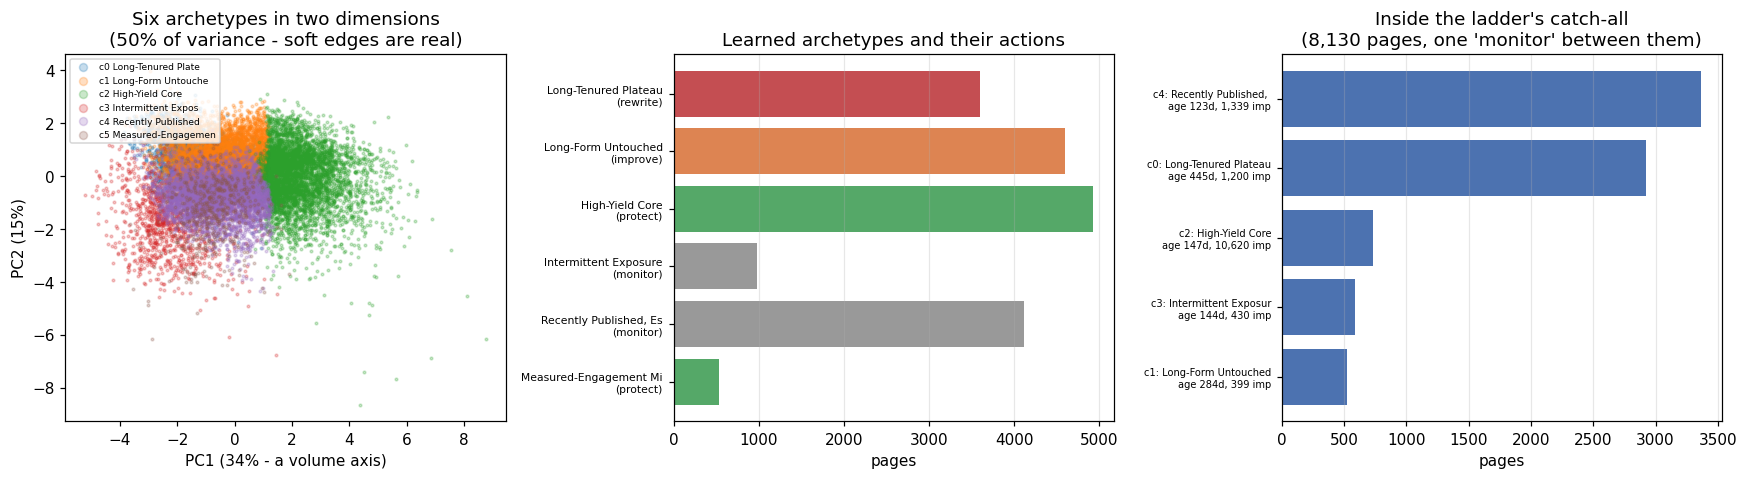

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

proj = pca.transform(X)
for cl in range(K):
    m = km.labels_ == cl
    axes[0].scatter(proj[m, 0], proj[m, 1], s=3, alpha=0.25, label=f"c{cl} {NAMES[cl][:18]}")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% - a volume axis)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axes[0].set_title("Six archetypes in two dimensions\n(50% of variance - soft edges are real)")
axes[0].legend(fontsize=6, markerscale=3, loc="upper left")

order = list(range(K))
colors = {"protect": "#55A868", "improve": "#DD8452", "rewrite": "#C44E52", "monitor": "#999999"}
axes[1].barh(order, [profile.loc[c, "pages"] for c in order],
             color=[colors[ACTIONS[c]] for c in order])
axes[1].set_yticks(order)
axes[1].set_yticklabels([f"{NAMES[c][:22]}\n({ACTIONS[c]})" for c in order], fontsize=7)
axes[1].invert_yaxis(); axes[1].set_xlabel("pages")
axes[1].set_title("Learned archetypes and their actions")
axes[1].grid(axis="x", alpha=0.3)

ins = inside.sort_values("pages", ascending=False)
axes[2].barh(range(len(ins)), ins["pages"], color="#4C72B0")
axes[2].set_yticks(range(len(ins)))
axes[2].set_yticklabels([f"c{c}: {NAMES[c][:20]}\nage {ins.loc[c,'age_days']:.0f}d, "
                         f"{ins.loc[c,'impressions']:,.0f} imp" for c in ins.index], fontsize=6.5)
axes[2].invert_yaxis(); axes[2].set_xlabel("pages")
axes[2].set_title(f"Inside the ladder's catch-all\n({len(steady):,} pages, one 'monitor' between them)")
axes[2].grid(axis="x", alpha=0.3)

fig.tight_layout()
Path("work/outputs").mkdir(parents=True, exist_ok=True)
fig.savefig("work/outputs/archetypes_vs_ladder.png", dpi=110, bbox_inches="tight")
print("saved work/outputs/archetypes_vs_ladder.png")
plt.show()

In [13]:
metrics = {
    "notebook": "w05_model.ipynb",
    "lane": "Lane 3 - Structured Content Archetype Clustering",
    "data": CSV_REL, "seed": SEED,
    "versions": {"sklearn": sklearn.__version__, "pandas": pd.__version__, "numpy": np.__version__},
    "inventory": {"pages": int(len(d)), "clients": int(d["client_id"].nunique()),
                  "min_impressions": MIN_IMPRESSIONS},
    "method": f"KMeans(k={K})", "k": K,
    "baseline_reproduced_from_ML07": repro,
    "method_comparison_silhouette": {
        "KMeans": round(float(sil_km), 4),
        "GaussianMixture": round(float(silhouette_score(X[samp], gm[samp])), 4),
        "Agglomerative_6k_subsample": round(float(silhouette_score(X[sub], agg)), 4)},
    "validation": {"seed_stability_ARI": round(float(np.mean(seed_ari)), 4),
                   "subsample_stability_ARI": round(float(np.mean(sub_ari)), 4),
                   "client_holdout_ARI_mean": round(float(np.mean(holdout_ari)), 4),
                   "client_holdout_ARI_range": [round(float(min(holdout_ari)), 4),
                                                round(float(max(holdout_ari)), 4)]},
    "agreement_with_ladder_ARI": round(float(ari_ladder), 4),
    "archetypes": {str(c): {"name": NAMES[c], "action": ACTIONS[c],
                            "pages": int(profile.loc[c, "pages"]),
                            "top_client_share": round(float(profile.loc[c, "top_client_share"]), 3)}
                   for c in range(K)},
    "distinct_actions": int(named["action"].nunique()),
    "catch_all_split": json.loads(inside[["pages", "impressions", "ctr", "age_days"]]
                                  .round(2).to_json(orient="index")),
    "verdict": ("K-Means beats GMM and Agglomerative on silhouette and splits the ladder's 8,130-page "
                "catch-all into 4+ distinct populations. But 6 clusters map to only 4 distinct actions, "
                "client-holdout ARI ranges 0.589-0.933, and PC1 is a volume axis - so the gain is real "
                "and smaller than the cluster count suggests."),
}
Path("work/outputs/model_metrics.json").write_text(json.dumps(metrics, indent=2))
print("wrote work/outputs/model_metrics.json  <- COMMIT THIS")
print(json.dumps({k: metrics[k] for k in
                  ["method_comparison_silhouette", "validation", "distinct_actions"]}, indent=2))

wrote work/outputs/model_metrics.json  <- COMMIT THIS
{
  "method_comparison_silhouette": {
    "KMeans": 0.2205,
    "GaussianMixture": 0.1164,
    "Agglomerative_6k_subsample": 0.1414
  },
  "validation": {
    "seed_stability_ARI": 0.9981,
    "subsample_stability_ARI": 0.9907,
    "client_holdout_ARI_mean": 0.809,
    "client_holdout_ARI_range": [
      0.5891,
      0.9326
    ]
  },
  "distinct_actions": 4
}


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere — pseudonymized ids only
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

### Card checklist
- [x] **Compares against the baseline on the same split** — the frozen ML-07 ladder is asserted to
      reproduce exactly (all five rung counts) before anything is fitted, and is scored on the same feature
      space with the same metric.
- [x] **Valid validation design** — seed stability, subsample stability, and a client-grouped holdout, with
      the holdout's unflattering range reported rather than its mean alone.
- [x] **Explains method choice** — K-Means against Gaussian Mixture and Agglomerative on identical inputs.
- [x] **Reports useful metrics** — silhouette (aggregate and per-page), ARI three ways, group sizes, client
      spread, PCA variance.
- [x] **Interprets clusters and errors** — profiles before names, action mapping, the duplicate-action
      failure, three worst-fitting pages with their nearest alternative cluster.
- [x] **Does not reward complexity alone** — the more expressive model (GMM) scored half the silhouette and
      was not shipped.

### What I actually claim

> On 18,752 pages from 29 pseudonymized clients, K-Means at k=6 produced six reproducible groups
> (seed ARI 0.998, subsample ARI 0.991) that **split the hand-written ladder's 8,130-page catch-all into at
> least four distinct populations** — including 735 pages with a median 10,620 impressions and 0.42% CTR
> that the ladder called "steady low", and a 2,920 vs 3,365 split separated by a 3.6× difference in content
> age at nearly identical volume and position.

And the three things that shrink that claim, all measured above:

1. **Six clusters, four distinct actions.** By the test I set in ML-03, two of the six do not earn separate
   treatment.
2. **Client-grouped holdout ARI ranges 0.589–0.933.** These archetypes are mostly, not reliably, portable
   to unseen clients.
3. **PC1 is a volume axis and carries 34% of the variance.** Volume is the dominant dimension. The lane
   passes the test ML-02 set for it — clusters 0 and 4 differ on age at equal volume, cluster 1 on length —
   but it passes narrowly.

Nothing here is causal, nothing is predictive, and no page should be pruned on cluster membership.

### What ML-09 (validation) gets
1. **Confidence-aware archetypes** — route negative-silhouette pages to `monitor` regardless of cluster.
   This came straight out of the error analysis.
2. **More holdout replicates**, and a leave-one-client-out version, so 0.589 becomes a distribution rather
   than an anecdote.
3. **Re-run without `engagement_rate`** and see whether the *Measured-Engagement Minority* survives. If it
   does not, that cluster was a measurement artefact and the action mapping loses a rung.
4. **Rebuild on the warehouse daily table** — a 90-day aggregate cannot tell a page that is *becoming* an
   archetype from one that has been it for a year, and the 445-day vs 123-day split is exactly the kind of
   distinction that needs trajectory to interpret.